# Исследовательский анализ рынка общественного питания г.Москвы

- Автор: Федорова Марина Вячеславовна
- Дата: 15.12.2025

### Цели и задачи проекта

Используем датасет с заведениями общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Будем работать с данными взятыми из открытых источников. Данные датасета хранят информацию о заведениях общественного питания и о среднем чеке.

### Описание данных

В проекте будут использованы два датасета `/datasets/rest_info.csv` и `/datasets/rest_price.csv`

Датасет `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:
* `id` - идентификатор заведения;
* `name` — название заведения;
* `address` — адрес заведения;
* `district` — административный район, в котором находится заведение, например Центральный административный округ;
* `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
* `hours` — информация о днях и часах работы;
* `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
* `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    * 0 — заведение не является сетевым;
    * 1 — заведение является сетевым.
* `seats` — количество посадочных мест.

Датасет `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
* `id` - идентификатор заведения;
* `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
* `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    * «Средний счёт: 1000–1500 ₽»;
    * «Цена чашки капучино: 130–220 ₽»;
    * «Цена бокала пива: 400–600 ₽» и так далее;
* `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:
    * Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    * Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    * Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
* `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:
    * Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    * Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    * Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.
   

### Содержимое проекта

<a class="ancor" id="17-bullet"></a>
### Содержание проекта

1. [Загрузка данных и знакомство с ними.](#1-bullet) 
2. [Предобработка данных.](#2-bullet) 
    * [Проверка типов данных.](#3-bullet)
    * [Поиск пропущенных значений.](#4-bullet)
    * [Поиск и обработка дубликатов.](#5-bullet)
    
    
3. [Исследовательский анализ данных.](#6-bullet)
    * [Распределение количества заведений по категориям](#7-bullet)
    * [Распределение количества заведений по округам](#8-bullet)
    * [Соотношение сетевых и несетевых заведений](#9-bullet)
    * [Распределение количества посадочных мест](#10-bullet)
    * [Исследование рейтинга заведений](#11-bullet)
    * [Исследование корреляции](#12-bullet)
    * [Топ-15 популярных сетей](#13-bullet)
    * [Анализ цен в зависимости от округа](#14-bullet)
    * [Промежуточный вывод](#15-bullet)
4. [Итоговый вывод и рекомендации.](#16-bullet)


---
<a class="ancor" id="1-bullet"></a>
## 1. Загрузка данных и знакомство с ними

Загрузим необходимые библиотеки для анализа данных и данные из датасета `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
# Импортируем библиотеки 
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
!pip install phik -U
from phik import phik_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Загружаем датасет /datasets/rest_info.csv в переменную info_rest
info_rest = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')

In [3]:
# Загружаем датасет /datasets/rest_price.csv в переменную price_rest
price_rest = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

***Выводим информацию о данных и первые строки датафрейма `info_rest`.***

In [4]:
# Выводим информацию о датафрейме info_rest
info_rest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [5]:
# Выводим первые строки датафрейма info_rest
info_rest.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0



### Промежуточный вывод

* Датасет `/datasets/rest_info.csv` содержит 8406 строк и 9 столбцов. 6 столбцов с типом данных  `object`, 2 столбца с типом данных `float64` и один столбец с целочисленным типом данных `int64`. 
* В столбцах `rating`, `chain` и `seats` можно провести оптимизацию типа данных с понижением разрядности, т.к. столбец `rating` содержит информацию о рейтинге и данные не превышают 5.0 единиц, столбец `chain` хранит число, которое показывает является ли заведение сетевым или нет и содержит значения 1 или 0, а в столбце `seats` содержится информация о количестве посадочных мест и если в столбце нет аномалий, то маловероятно, что он хранит высокие значения.
* Пропуски встречаются в в двух стобцах `hours` с информацией о режиме работы и `seats` с информацией о количестве посадочных мест.
* Данные в столбце могут содержать аномалии, т.к., судя по выведенным первым строкам в столбце `seats`, посадочных мест в ресторане `Четыре комнаты` всего лишь 4. 

---

***Выводим информацию о данных и первые строки датафрейма `price_rest`.***

In [6]:
# Выводим информацию о датафрейме price_rest
price_rest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [7]:
# Выводим первые строки датафрейма price_rest
price_rest.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


### Промежуточный вывод

* Датасет `/datasets/rest_price.csv` содержит 4058 строк и 5 столбцов. 3 столбца с типом данных  `object`, 2 столбца с типом данных `float64`. 
* В столбцах `middle_avg_bill` и `middle_coffee_cup` можно провести оптимизацию типа данных с понижением разрядности и если в столбце нет аномалий, то маловероятно, что он хранит высокие значения.
* Пропуски встречаются почти во всех столбцах. Единственный столбец без пропущенных значений `id`, который содержит идентификатор заведения.
* Данные, на первый взгляд, корректны и соответствуют описанию. Названия столбцов в едином стиле.

---

### Подготовка единого датафрейма

Объединим два датафрейма для дальнейшего анализа данных с помощью параметра `how='outer'` метода `merge()`, для того чтобы сохранит данные из обоих датафреймов.

In [8]:
# Объединим датафреймы info_rest и price_rest 
df_rest = info_rest.merge(price_rest, how='outer', on='id')

In [9]:
# Выводим информацию о новом датафрейме df_rest
df_rest.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [10]:
# Выводим первые строки нового датафрейма df_rest
df_rest.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


После объединения новый датафрейм содержит 8406 строк и 13 столбцов.

[Назад к содержанию](#17-bullet)

In [11]:
# Создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp = df_rest.copy() 
len(temp)

8406

---
<a class="ancor" id="2-bullet"></a>
## 2. Предобработка данных

Подготовим данные к исследовательскому анализу


<a class="ancor" id="3-bullet"></a>
### 2.1. Типы данных
Проведем оптимизацию типов данных путем понижения их разрядности.

In [12]:
# Оптимизируем тип данных float64
for column in ['rating', 'seats', 'middle_avg_bill', 'middle_coffee_cup']:
    df_rest[column] = pd.to_numeric(df_rest[column], downcast='float')

In [13]:
# Оптимизируем целочисленный тип данных в столбце 'chain'
df_rest['chain'] = pd.to_numeric(df_rest['chain'], downcast='integer')

[Назад к содержанию](#17-bullet)

<a class="ancor" id="4-bullet"></a>
### 2.2. Наличие пропусков в данных

При первичном анализе мы обнаружили пропуски в датафрейме df_rest. Узнаем абсолютное и относительное количество пропусков в каждом столбце датафрейма

In [14]:
# Выводим абсолютное и относительное количесвто пропусков в датафрейме
def show_missing_stats(tmp0):
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df_rest)

,Кол-во пропусков,Доля пропусков
hours,536,0.0638
seats,3611,0.4296
price,5091,0.6056
avg_bill,4590,0.5460
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


В датафрейме `df_rest` пропущенные значения встречаются в 6 столбцах. Пропуски в данных, предположительно, присутствуют из-за неполной информации в общедоступных источниках. 
* В столбце `hours` пропуски заменим на значение-индикатор.
* В остальных столбцах оставим пропущенные значения как есть, чтобы не портить статистические данные.

Перед обработкой столбцов с пропусками проверим статистические данные методом `describe()`. Метод `describe()` не учитывает данные с пропусками.

In [15]:
df_rest.describe()

,rating,chain,seats,middle_avg_bill,middle_coffee_cup
count,8406.000000,8406.000000,4795.000000,3149.000000,535.000000
mean,4.229895,0.381275,108.421692,958.053650,174.721497
std,0.470348,0.485729,122.833397,1009.732849,88.951103
min,1.000000,0.000000,0.000000,0.000000,60.000000
25%,4.100000,0.000000,40.000000,375.000000,124.500000
50%,4.300000,0.000000,75.000000,750.000000,169.000000
75%,4.400000,1.000000,140.000000,1250.000000,225.000000
max,5.000000,1.000000,1288.000000,35000.000000,1568.000000


Пропуски в столбце `hours` заменим на значение-индикатор.

In [16]:
df_rest['hours'] = df_rest['hours'].fillna(-1)

In [17]:
# Проверим оставшиеся пропущенные значения
show_missing_stats(df_rest)

,Кол-во пропусков,Доля пропусков
seats,3611,0.4296
price,5091,0.6056
avg_bill,4590,0.5460
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


[Назад к содержанию](#17-bullet)

---
<a class="ancor" id="5-bullet"></a>
### 2.3. Явные и неявные дубликаты в данных

Проверим данные на наличие явных дубликатов. Затем переведем названия заведений и адрес в нижний регистр и удалим лишние пробелов в начале и в конце строки для более точной проверки на наличие неявных дубликатов. 

In [18]:
# Проверим полные дубликаты в датафрейме
df_rest.duplicated().sum()

0

В датафрейме нет полных дубликатов строк. Проверим неявные дубликаты.

In [19]:
# Переводим строки столбца 'name' в нижний регистр
df_rest['name'] = df_rest['name'].str.lower()

In [20]:
# Удалим лишние пропуски в столбце с названиями заведения
df_rest['name'] = df_rest['name'].str.strip()

In [21]:
# Переводим строки столбца 'address' в нижний регистр
df_rest['address'] = df_rest['address'].str.lower()

In [22]:
# Удалим лишние пропуски в столбце с адресом
df_rest['address'] = df_rest['address'].str.strip()

In [23]:
# Проверяем неявные дубликаты по 'name' и 'address'
duplicates = df_rest[df_rest.duplicated(subset=['name', 'address'])] 
display(duplicates)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,-1,4.1,0,276.0,NaN,NaN,NaN,NaN


Количество дубликатов - 4. Прежде чем удалить дубликаты, отсортируем датафрейм по всем столбцам.

In [24]:
# Сортируем датафрейм по всем столбцам
df_rest_sorted = df_rest.sort_values(by=list(df_rest.columns))

In [25]:
# Удаляем дубликаты 
df_rest = df_rest_sorted.drop_duplicates(subset=['name', 'address'], keep='first')

In [26]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['category', 'district']:
    display(f'Уникальные значения в столбце {column}:')
    display(df_rest[column].sort_values().unique())
    display() 

'Уникальные значения в столбце category:'

array(['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня',
       'пиццерия', 'ресторан', 'столовая'], dtype=object)

'Уникальные значения в столбце district:'

array(['Восточный административный округ',
       'Западный административный округ',
       'Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Центральный административный округ',
       'Юго-Восточный административный округ',
       'Юго-Западный административный округ',
       'Южный административный округ'], dtype=object)

В столбцах `category` и `district` нет ошибок.

Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.


In [27]:
# Переводим строки столбца 'hours' в нижний регистр
df_rest.loc[:, 'hours'] = df_rest['hours'].str.lower()

In [28]:
# Создадим функцию для проверки условия режима работы
def is_24_7 (row):
    if row['hours'] == 'ежедневно, круглосуточно':
        return True
    else:
        return False

In [29]:
# Применим функцию и создадим новый столбец 'is_24_7'
df_rest.loc[:, 'is_24_7'] = df_rest.apply(is_24_7, axis=1)

In [30]:
# Проверим данные столбца
df_rest['is_24_7'].value_counts()

False    7672
True      730
Name: is_24_7, dtype: int64

In [31]:
# Выводим первые строки для проверки
df_rest.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
61,0009f005d6fb47c6b067db5084f4e05a,кафе лоза,ресторан,"москва, череповецкая улица, 4а",Северо-Восточный административный округ,"ежедневно, круглосуточно",4.2,0,85.0,средние,Средний счёт:500–800 ₽,650.0,NaN,True
3414,000c4f8e2c6b4a8e81127ed094688658,добролавка,кофейня,"москва, столярный переулок, 3к13",Центральный административный округ,"пн-пт 09:00–21:00; сб,вс 10:00–21:00",4.4,0,NaN,средние,Цена чашки капучино:150–190 ₽,NaN,170.0,False
2581,0028eb1543284e18a0acdb0343a66107,кафе бульвар. шашлык-сити,кафе,"москва, 7-я парковая улица, 15, стр. 3",Восточный административный округ,"ежедневно, 11:00–00:00",4.3,0,NaN,NaN,NaN,NaN,NaN,False
6866,002a2a1a30b84ad1883408ad5cec661f,булошная,кофейня,"москва, новочерёмушкинская улица, 58",Юго-Западный административный округ,"ежедневно, 09:00–22:00",4.4,1,20.0,NaN,NaN,NaN,NaN,False
2314,002c7e0b7c294daf944229bc10597566,j&j cafe moscow,кофейня,"москва, верхняя красносельская улица, 16",Центральный административный округ,пн-пт 09:00–18:00,4.1,0,NaN,средние,Цена чашки капучино:170–250 ₽,NaN,210.0,False


[Назад к содержанию](#17-bullet)

---

### Промежуточный вывод


In [32]:
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df_rest)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


В процессе предобработки данных заменили пропуски значением-индикатором в столбце `hours` в количестве 536 строк. И удалили строки с выявленными дубликатами. Процент удаленных строк составляет 0.05.
Также оптимизировали типы данных путем понижения их разрядности в столбцах `rating`, `seats`, `middle_avg_bill`, `middle_coffee_cup` и `chain`.

[Назад к содержанию](#17-bullet)

---
<a class="ancor" id="6-bullet"></a>
## 3. Исследовательский анализ данных
Проведём исследовательский анализ исходных данных. При исследовании данных используем визуализации. 


---
<a class="ancor" id="7-bullet"></a>
### Распределение количества заведений по категориям

Исследуем количество объектов общественного питания по каждой категории. 

In [33]:
# Найдем уникальные значения категории заведения
df_rest['category'].unique()

array(['ресторан', 'кофейня', 'кафе', 'бар,паб', 'быстрое питание',
       'пиццерия', 'столовая', 'булочная'], dtype=object)

In [34]:
# Проверяем распределение данных по значениям столбца 'category'
display('Количество заведений общественного питания по каждой категории:')
df_rest['category'].value_counts() 

'Количество заведений общественного питания по каждой категории:'

кафе               2376
ресторан           2041
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

In [35]:
# Проверяем распределение данных по значениям столбца 'category' в относительных значениях
display('Количество заведений в относительном значении по каждой категории:')
df_rest['category'].value_counts(normalize=True) 

'Количество заведений в относительном значении по каждой категории:'

кафе               0.282790
ресторан           0.242918
кофейня            0.168174
бар,паб            0.091050
пиццерия           0.075339
быстрое питание    0.071769
столовая           0.037491
булочная           0.030469
Name: category, dtype: float64


Построим столбчатую диаграмму для наглядного сравнения:

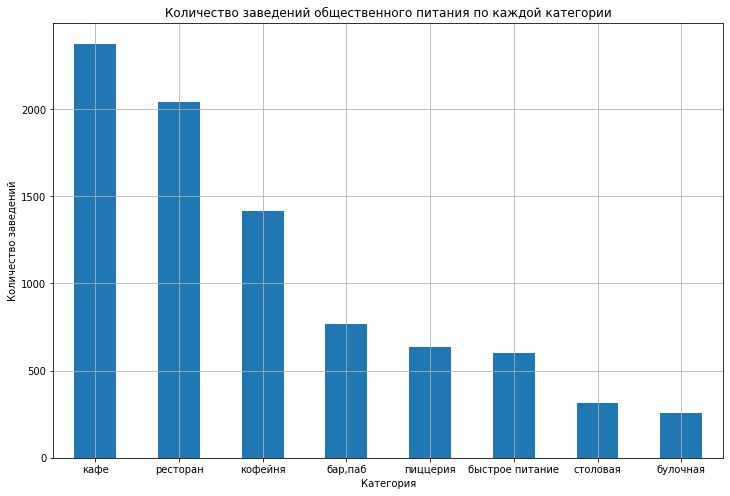

In [36]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 8))

# Строим столбчатую диаграмму
df_rest['category'].value_counts().plot(
                    kind='bar',
                    rot='0',
                    legend=False,
                    title='Количество заведений общественного питания по каждой категории')

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid()
# Выводим график
plt.show()

Категории `кафе` и `ресторан` значительно превышают в количестве остальные заведения. `Кафе` абсолютный лидер - `2378` заведений по г.Москве. `Ресторанов` немного меньше - `2043` заведений. В меньшинстве категории `столовая` - `315` и `булочная` всего `256` заведений.

[Назад к содержанию](#17-bullet)

---
<a class="ancor" id="8-bullet"></a>
### Распределение количества заведений по округам

Исследуем распределение количества заведений по административным районам Москвы, а также отдельно рассмотрим распределение заведений каждой категории в Центральном административном округе Москвы. 

In [37]:
# Проверяем распределение данных по значениям столбца 'district'
display('Количество заведений общественного питания по административным округам:')
df_rest['district'].value_counts() 

'Количество заведений общественного питания по административным округам:'

Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

In [38]:
# Проверяем распределение данных по значениям столбца 'district'
display('Количество заведений по административным округам в относительном значении:')
df_rest['district'].value_counts(normalize=True) 

'Количество заведений по административным округам в относительном значении:'

Центральный административный округ         0.266841
Северный административный округ            0.106879
Южный административный округ               0.106165
Северо-Восточный административный округ    0.105927
Западный административный округ            0.101166
Восточный административный округ           0.094977
Юго-Восточный административный округ       0.084980
Юго-Западный административный округ        0.084385
Северо-Западный административный округ     0.048679
Name: district, dtype: float64

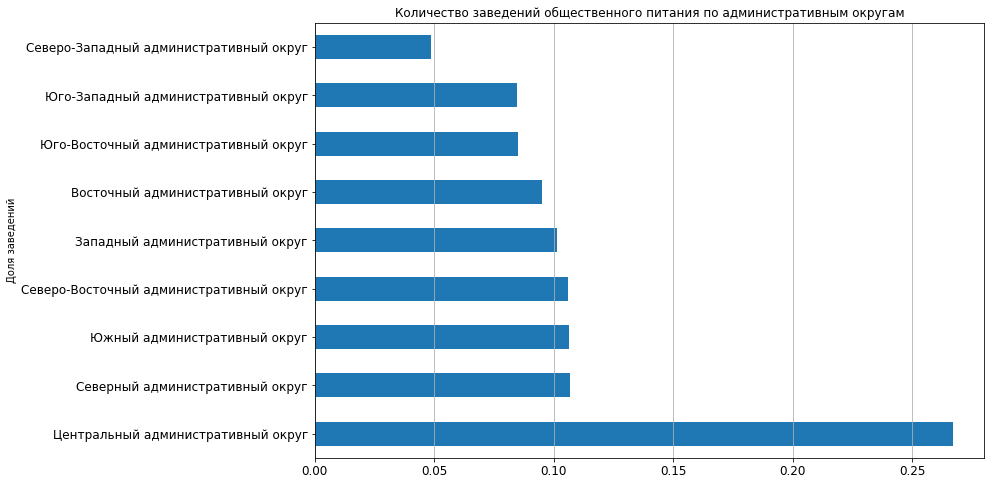

In [39]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 8))

# Строим линейчатую диаграмму
df_rest['district'].value_counts(normalize=True).plot(
                    kind='barh',
                    xlabel='Доля заведений',
                    ylabel='Административный округ',
                    rot='0',
                    legend=False,
                    title='Количество заведений общественного питания по административным округам')

# Увеличим размер шрифта меток на осях
plt.gca().tick_params(axis='both', which='major', labelsize=12)

# Добавляем сетку графика
plt.grid(axis='x')
# Выводим график
plt.show()

Судя по распределению, основная часть в количестве `2242` заведений находятся в `Центральном административном округе`. 

Исследуем распределение заведений каждой категории в `Центральном административном округе` Москвы:

In [40]:
# Фильтруем по округу и выводим количество заведений по округу
filtered_df_rest = df_rest[df_rest['district'] == 'Центральный административный округ']

display('Количество заведений в Центральном административном округе:')
filtered_df_rest['category'].value_counts()

'Количество заведений в Центральном административном округе:'

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

In [41]:
# Выводим относительное значений заведений
display('Количество заведений в Центральном административном округе:')
filtered_df_rest['category'].value_counts(normalize=True)

'Количество заведений в Центральном административном округе:'

ресторан           0.298840
кафе               0.206958
кофейня            0.190901
бар,паб            0.162355
пиццерия           0.050401
быстрое питание    0.038805
столовая           0.029438
булочная           0.022302
Name: category, dtype: float64

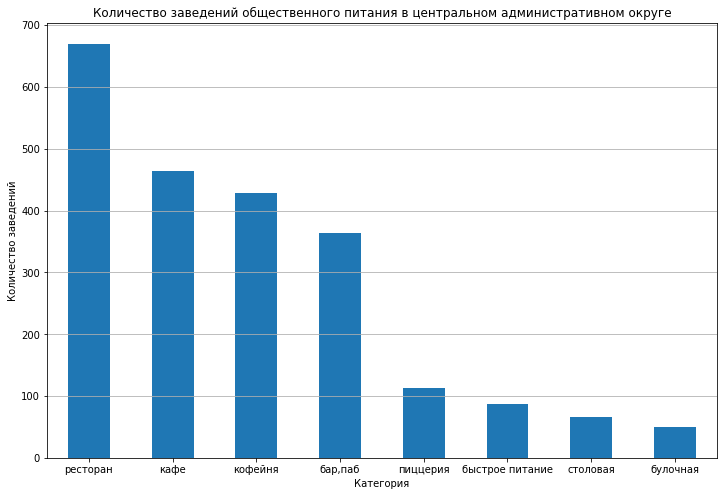

In [42]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 8))

# Строим столбчатую диаграмму
filtered_df_rest['category'].value_counts().plot(
                    kind='bar',
                    rot='0',
                    legend=False,
                    title='Количество заведений общественного питания в центральном административном округе')

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid(axis='y')
# Выводим график
plt.show()

В `Центральном административном округе` количество `ресторанов` превышает остальные заведения общественного питания и составляет `670`. `Кафе` и `кофейни` практически в одинаковом количестве, `464` и `428`, соответственно. `Булочные` всё также в меньшинстве `50` заведений.
Количество заведений в Центральном районе Москвы более чем в два раза превышает распределение заведений по остальным административным округам. Меньше всего заведений в `Северо-Западном административном округе` - `409` заведений. 

[Назад к содержанию](#17-bullet)

---
<a class="ancor" id="9-bullet"></a>
### Соотношение сетевых и несетевых заведений

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Выясним каких заведений больше — сетевых или несетевых и какие категории заведений чаще являются сетевыми.

In [43]:
# Проверяем распределение данных по значениям столбца 'chain'
display('Количество заведений общественного питания:')
df_rest['chain'].value_counts() 

'Количество заведений общественного питания:'

0    5198
1    3204
Name: chain, dtype: int64

In [44]:
# Проверяем распределение данных по значениям столбца 'chain'
display('Доля заведений общественного питания:')
df_rest['chain'].value_counts(normalize=True) 

'Доля заведений общественного питания:'

0    0.618662
1    0.381338
Name: chain, dtype: float64

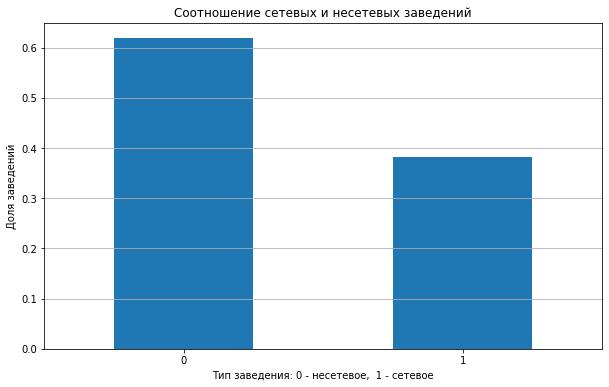

In [45]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму
df_rest['chain'].value_counts(normalize=True).plot(
                    kind='bar',
                    rot='0',
                    title='Соотношение сетевых и несетевых заведений')

# Настраиваем оформление графика
plt.xlabel('Тип заведения: 0 - несетевое,  1 - сетевое')
plt.ylabel('Доля заведений')
# Добавляем сетку графика
plt.grid(axis='y')
# Выводим график
plt.show()

По результатам исследования и диаграмме можно сказать, что `несетевых` заведений общественного питания больше. Доля `несетевых` заведений составляет примерно `62 %`.

In [46]:
# Создаём таблицу, которая группирует данные по 'chain' и 'category'
grouped_df_rest = df_rest.groupby('category')['chain'].value_counts(normalize=True).unstack(fill_value=0).reset_index()
# Выводим результат
display(grouped_df_rest)

chain,category,0,1
0,"бар,паб",0.779085,0.220915
1,булочная,0.386719,0.613281
2,быстрое питание,0.615257,0.384743
3,кафе,0.672138,0.327862
4,кофейня,0.490446,0.509554
5,пиццерия,0.478673,0.521327
6,ресторан,0.642822,0.357178
7,столовая,0.720635,0.279365


In [47]:
# Переименуем столбцы 0 и 1 датафрейма grouped_df_rest
grouped_df_rest = grouped_df_rest.rename(columns={0: 'chain_0', 1: 'chain_1'})


Построим столбчатые диаграммы для визуализации распределения сетевых и несетевых заведений в разрезе категорий:

<Figure size 1008x432 with 0 Axes>

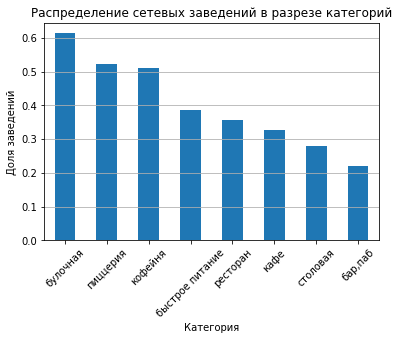

In [48]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(14, 6))


# Строим столбчатую диаграмму
grouped_df_rest.sort_values(by='chain_1', ascending=False).plot(
                    kind='bar',
                    x='category',
                    y='chain_1',
                    rot='45',
                    legend=False,
                    title='Распределение сетевых заведений в разрезе категорий')

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Доля заведений')

# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

<Figure size 864x432 with 0 Axes>

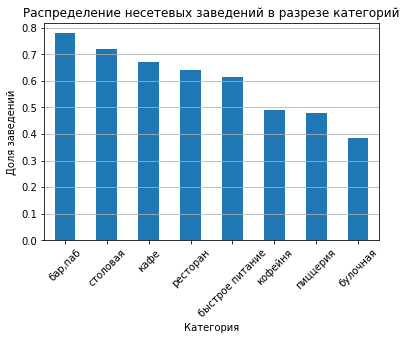

In [49]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму
grouped_df_rest.sort_values(by='chain_0', ascending=False).plot(
                    kind='bar',
                    x='category',
                    y='chain_0',
                    rot='45',
                    legend=False,
                    title='Распределение несетевых заведений в разрезе категорий')

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Доля заведений')

# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

Судя по диаграмме распределений заведений "сети" и "не сети", `булочные` чаще являются сетевыми (их доля составляет `61.33 %`), на втором месте `пиццерии` (`52.13 %`), за ними - `кафе` (`50.96 %`). 

`Бары и пабы` реже являются сетевыми, всего `22.09 %`, также как и `столовые` - `28 %`.

[Назад к содержанию](#17-bullet)

---
<a class="ancor" id="10-bullet"></a>
### Распределение количества посадочных мест

Исследуем количество посадочных мест в заведениях. Выясним встречаются ли в данных аномальные значения или выбросы. Приведём для каждой категории заведений наиболее типичное для него количество посадочных мест.


In [50]:
# Изучаем статистические показатели столбца 'seats'
display('Статистические показатели столбца seats:')
df_rest['seats'].describe()

'Статистические показатели столбца seats:'

count    4792.000000
mean      108.361435
std       122.841133
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

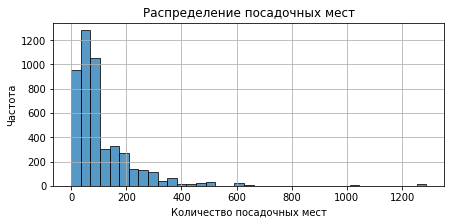

In [51]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df_rest['seats'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=37, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

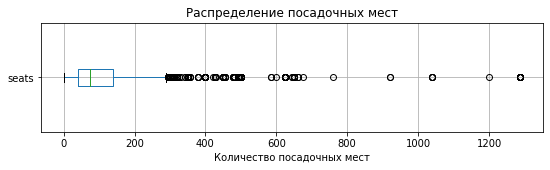

In [52]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(9, 2))

# Строим диаграмму размаха значений в столбце seats
df_rest.boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение посадочных мест')
plt.xlabel('Количество посадочных мест')

# Выводим график
plt.show()

Распределение количества посадочных мест асимметричное, скошенное вправо. `Минимальный количество — 0`, а `максимальный — 1288`, что вполне может соответствовать действительности. `Среднее значение` соответствует `88 посадочных мест`, тогда как `медиана — 60`. Среднее и медианное значение достаточно далеки друг от друга, это может свидетельствовать о наличии выбросов или асимметрии в наборе данных. `Стандартное отклонение` достаточно высокое `98.21`, это указывает, что данные могут иметь широкий разброс. Разница между минимальным и максимальным значениями это подтверждает.

Приведём для каждой категории заведений наиболее типичное для него количество посадочных мест.

In [53]:
# Группируем данные по категориям и находим медиану количества посадочных мест
df_rest.groupby('category')['seats'].agg('median')

category
бар,паб            82.5
булочная           50.0
быстрое питание    65.0
кафе               60.0
кофейня            80.0
пиццерия           55.0
ресторан           86.0
столовая           75.5
Name: seats, dtype: float32

<Figure size 864x432 with 0 Axes>

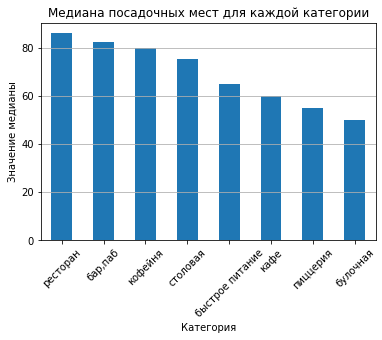

In [54]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 6))

grouped_df_seats = df_rest.groupby('category')['seats'].agg('median').reset_index()

# Строим столбчатую диаграмму
grouped_df_seats.sort_values(by='seats', ascending=False).plot(
                    kind='bar',
                    x='category',
                    rot='45',
                    legend=False,
                    title='Медиана посадочных мест для каждой категории')

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Значение медианы')

# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

Графики показали большой разброс в столбце `seats`, но это не означает, что данные являются аномалиями или выбросами. Возможно, действительно есть заведения с таким большим количеством посадочных мест. Нулевые значения также не являются выбросами. Часто в заведениях типа `булочная`, `быстрое питание` или `кофейня` нет посадочных мест. 

Самое меньшеее значение медианы количества посадочных мест соответствует `булочным` - `50` п.м, что не так уж и мало для такого типа заведения. `Рестораны`, `бары и пабы` имеют большее количество посадочных мест - их медиана составляет `86` и `82.5` п.м. соответственно.

[Назад к содержанию](#17-bullet)

---
<a class="ancor" id="11-bullet"></a>
### Исследование рейтинга заведений

Исследуем рейтинг заведений. Визуализируем распределение средних рейтингов по категориям заведений. Выясниим сильно ли различаются усреднённые рейтинги для разных типов общепита.

In [55]:
# Изучаем статистические показатели столбца 'rating'
display('Статистические показатели столбца rating:')
df_rest['rating'].describe()

'Статистические показатели столбца rating:'

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

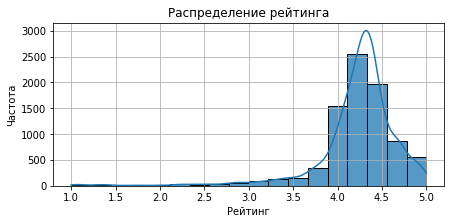

In [56]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью seaborn
sns.histplot(data=df_rest, 
             x='rating',
             bins=18,
             kde=True,
             alpha=0.75,
             edgecolor='black', 
)

# Настраиваем оформление графика
plt.title('Распределение рейтинга')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Найдём среднне значение для каждой категории заведения общественного питания:


In [57]:
# Группируем среднее значение рейтинга по категориям
#group_df_rest = df_rest.groupby('category')['rating'].mean()
#display(group_df_rest)

In [58]:
group_df_rest = df_rest.groupby('category')['rating'].describe()
display(group_df_rest)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",765.0,4.387712,0.380143,1.1,4.3,4.4,4.6,5.0
булочная,256.0,4.268359,0.386303,1.3,4.2,4.3,4.4,5.0
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0
кафе,2376.0,4.124285,0.566001,1.0,4.0,4.2,4.4,5.0
кофейня,1413.0,4.277283,0.372250,1.4,4.1,4.3,4.4,5.0
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
ресторан,2041.0,4.290348,0.413237,1.0,4.2,4.3,4.5,5.0
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0


Построим график распределения среднего значения по категориям, чтобы посмотреть насколько сильно различается усреднённый рейтинг для разных типов общественного питания:

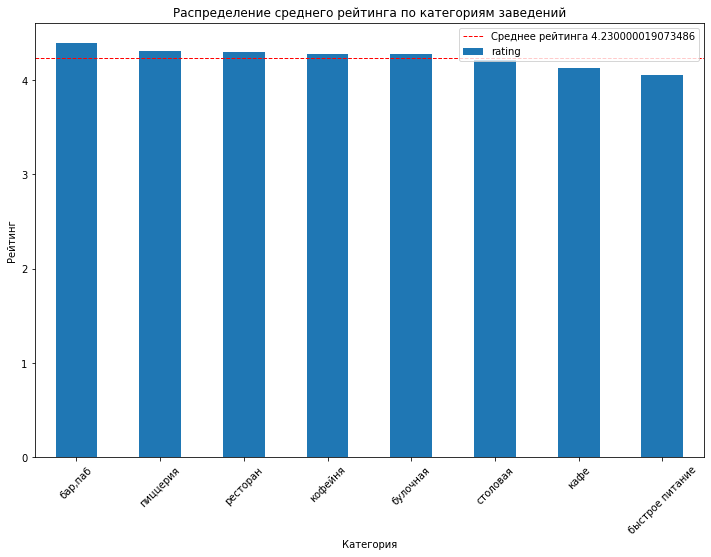

In [59]:
# Строим график столбчатой диаграммы
group_df_rest_mean = df_rest.groupby('category')['rating'].mean().reset_index()

group_df_rest_mean.sort_values('rating', ascending=False).plot(
            kind='bar',
            x='category',
            title='Распределение среднего рейтинга по категориям заведений',   
            rot=45,
            figsize=(12, 8))

# Рассчитываем среднее значение рейтинга
mean_rating_share = df_rest['rating'].mean()

# Наносим на график линию с средним значением доли нелояльных клиентов
plt.axhline(mean_rating_share,
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Среднее рейтинга {round(mean_rating_share, 2)}')

# Оформляем график
plt.xlabel('Категория')
plt.ylabel('Рейтинг')
plt.legend()

# Выводим график
plt.show() 

Распределение данных на гистограмме выглядит нормальным, однако характеризуется широким разбросом и «хвостом» в левой части гистограммы. Такие низкие значения не являются выбросами и могут говорить о низком рейтинге заведения, что вполне естественно. 

Среднее значение и медиана находятся рядом.

Распределение среднего значения рейтинга по категориям заведения показывает, что рейтинги заведений `быстрое питание` и `кафе` ниже общего среднего значения. 

[Назад к содержанию](#17-bullet)

---
<a class="ancor" id="12-bullet"></a>
### Исследование корреляции

Изучим с какими данными показывают самую сильную корреляцию рейтинги заведений. Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберем самую сильную связь и проверим её.

In [60]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df_rest[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']].phik_matrix()

# Выводим результат
display('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False) 

interval columns not set, guessing: ['rating', 'chain', 'seats']


'Корреляционная матрица с коэффициентом phi_k для переменной rating'

,rating
price,0.262056
category,0.198763
district,0.189453
is_24_7,0.161010
chain,0.118785
seats,0.000000


Наибольшая корреляция рейтинга наблюдается с `ценовой категорией` заведения (`0.26`), `категорией заведения` (`0.20`) и `административным округом` (`0.19`). Для остальных признаков коэффициент корреляции снижается с `0.16` до `0`. Важно помнить, что phi_k сообщает только о наличии связи между данными. На сам характер связи коэффициент phi_k не указывает, поэтому после получения коэффициента продолжим анализ.

Визуализируем результат корреляции с помощью тепловой карты:

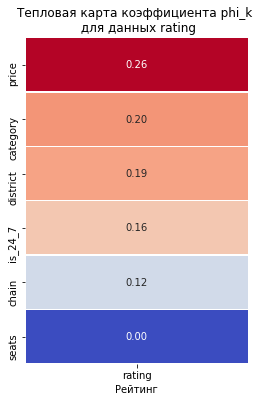

In [61]:
# Строим тепловую карту
plt.figure(figsize=(4, 6))

# Сохраняем матрицу корреляции признака rating с другими признаками
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            linewidths=0.5, 
            cbar=False 
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг')

# Выводим график
plt.show() 

Изучим зависимость рейтинга и ценовой категорией заведения:

In [62]:
# Выводим расчёт значения среднего рейтинга для ценовых категорий заведения 
display('Среднее значение рейтинга в зависимости от ценовой категории:')

df_grouped = df_rest.groupby('price')['rating'].mean().reset_index()

display(df_grouped.sort_values(by='rating'))

'Среднее значение рейтинга в зависимости от ценовой категории:'

,price,rating
2,низкие,4.173077
3,средние,4.297874
1,выше среднего,4.386348
0,высокие,4.436611


<Figure size 864x576 with 0 Axes>

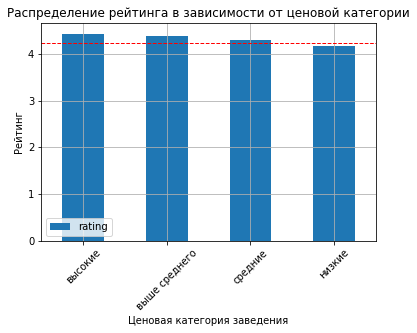

In [63]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 8))

# Строим график столбчатой диаграммы
df_grouped = df_rest.groupby('price')['rating'].mean().reset_index()
df_grouped.sort_values('rating', ascending=False).plot(
            kind='bar',
            x='price',
            xlabel='Ценовая категория заведения',
            ylabel='Рейтинг',
            title='Распределение рейтинга в зависимости от ценовой категории',   
            rot=45)
    
# Рассчитываем среднее значение рейтинга
mean_rating_share = df_rest['rating'].mean()

# Наносим на график линию с средним значением доли нелояльных клиентов
plt.axhline(mean_rating_share,
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Среднее рейтинга {round(mean_rating_share, 2)}')

# Добавляем сетку на график
plt.grid()

# Выводим график
plt.show() 

По диаграмме видно, что более низкий рейтинг у заведений с `низкой` ценовой категорией. Высокие рейтинги у заведений с `высокой` и `выше среднего` ценовых категорий. 

Изучим зависимость рейтинга и местоположением:

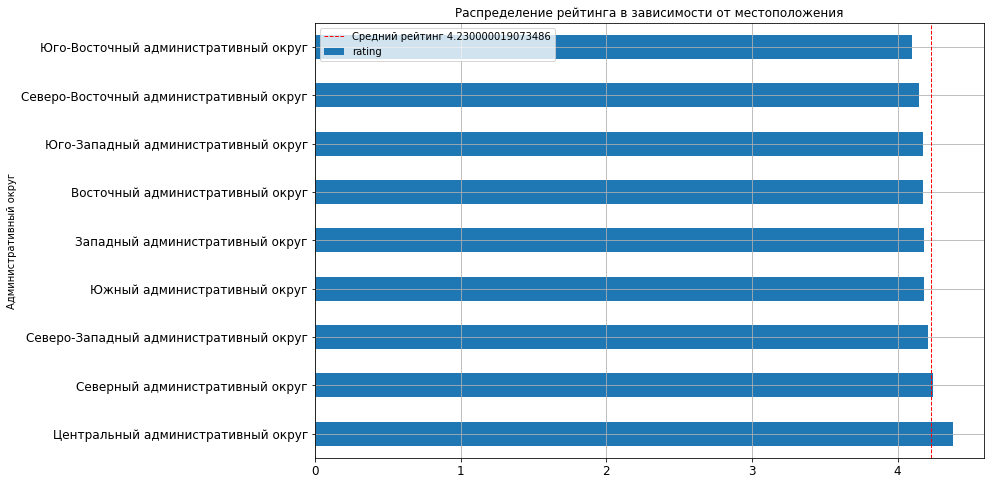

In [64]:
# Строим график столбчатой диаграммы
grouped = df_rest.groupby('district')['rating'].mean().reset_index()

grouped.sort_values(by='rating', ascending=False).plot(
    kind='barh',
    x='district',
    xlabel='Административный округ',
    ylabel='Рейтинг',
    title=f'Распределение рейтинга в зависимости от местоположения',
    rot=0,
    figsize=(12, 8))

# Рассчитываем среднее значение по рейтинга
mean_rating_share = df_rest['rating'].mean()

# Наносим на график линию с средним значением рейтинга
plt.axvline(mean_rating_share, 
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Средний рейтинг {round(mean_rating_share,4)}')

# Увеличим размер шрифта меток на осях
plt.gca().tick_params(axis='both', which='major', labelsize=12)

# Добавляем сетку в график
plt.grid()

# Добавляем легенду
plt.legend()

# Выводим график
plt.show() 

Судя по диаграмме, самые высокие рейтинги в `Центральном` административном округе. В `Восточном`, `Северо-Восточном`, `Юго-Восточном` и `Юго-Западном` административных округах средние рейтинги ниже общего среднего значения.

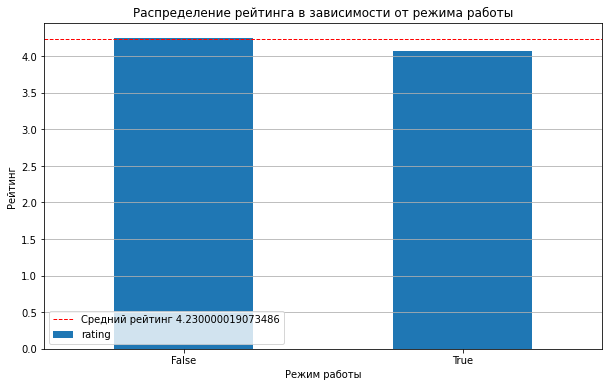

In [65]:
# Строим график столбчатой диаграммы
grouped = df_rest.groupby('is_24_7')['rating'].mean()
grouped.plot(kind='bar',
               title=f'Распределение рейтинга в зависимости от режима работы',
               ylabel='Рейтинг',
               xlabel='Режим работы',
               rot=0,
               figsize=(10, 6))

# Рассчитываем среднее значение по рейтинга
mean_rating_share = df_rest['rating'].mean()

# Наносим на график линию с средним значением рейтинга
plt.axhline(mean_rating_share, 
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Средний рейтинг {round(mean_rating_share,4)}')

plt.grid(axis='y')
plt.legend()

# Выводим график
plt.show() 

На графике (где True - это заведения, которые работают круглосуточно) показано, что у круглосуточных заведений рейтинг ниже.

Результат корреляции показал, что самая сильная связь `рейтинга` заведения с `ценовой категорией`. Проанализировав значение среднего рейтинга по отношению к ценовой категории можно заметить, что заведения с `высокой ценовой категорий` имеют `высокое значение` среднего рейтинга, а заведения с `низкой ценовой категорией` - `низкое значение`. 

По местоположению заведения `высокое значение` среднего рейтинга встречается в заведениях `Центрального административного округа`. 

Заведения, которые работают в `круглосуточном` режиме имеют `ниже значение` среднего рейтинга, чем заведения с альтернативным режимом работы.

[Назад к содержанию](#17-bullet)

---
<a class="ancor" id="13-bullet"></a>
### Топ-15 популярных сетей

Сгруппируем данные по названиям заведений и найдём топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. Выясним к какой категории заведений они относятся. Результат сопроводим подходящими визуализациями.

In [66]:
# Фильтруем значение столбца 'chain' по признаку сети
filtered_df_rest = df_rest[df_rest['chain'] == 1]

# Сгруппируем данные по названию заведений
grouped = filtered_df_rest.groupby(['name', 'category']).size().reset_index(name='count')

# Найдем топ-15 популярных сетей
sort_grouped = grouped.sort_values(by='count', ascending=False)

#Посчитаем рейтинг для популярных сетей
def mean_rating(name):
    return df_rest[df_rest['name'] == name]['rating'].mean()

# Применим функцию и добавим результат в новый столбец
sort_grouped['mean_rating'] = sort_grouped['name'].apply(mean_rating)

# Выясним к какой категории относится каждое заведение
def estab_category(name):
    return df_rest[df_rest['name'] == name]['category'].iloc[0]

# Применим функцию и добавим результат в новый столбец
sort_grouped['estab_category'] = sort_grouped['name'].apply(estab_category)

top_15 = sort_grouped.head(15)

display('Топ-15 популярных сетей в Москве')
display(top_15)

'Топ-15 популярных сетей в Москве'

,name,category,count,mean_rating,estab_category
1126,шоколадница,кофейня,119,4.177500,кофейня
496,домино'с пицца,пиццерия,76,4.171429,пиццерия
489,додо пицца,пиццерия,74,4.286487,пиццерия
205,one price coffee,кофейня,71,4.069445,кофейня
1142,яндекс лавка,ресторан,69,3.872464,ресторан
72,cofix,кофейня,65,4.075385,кофейня
241,prime,ресторан,49,4.116000,ресторан
617,кофепорт,кофейня,42,4.147619,кофейня
632,кулинарная лавка братьев караваевых,кафе,39,4.394871,кафе
963,теремок,ресторан,36,4.123684,ресторан


Построим линейчатую диаграмму популярных сетевых заведений:

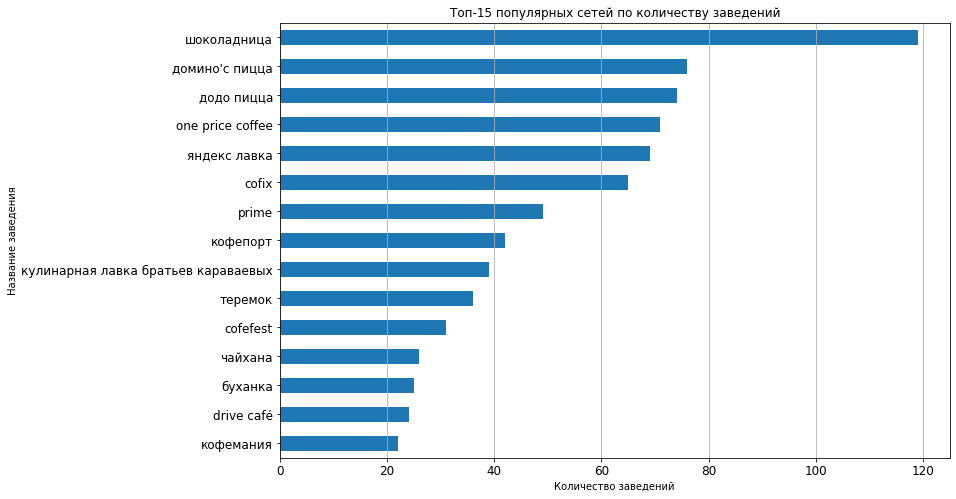

In [83]:
# Построим линейчатую диаграмму с результатом
top_15.sort_values(by='count', ascending=True).plot(
    kind='barh', 
    x='name', 
    y='count',
    xlabel='Название заведения',
    figsize=(12, 8),
    legend=False,
    title=('Топ-15 популярных сетей по количеству заведений'))

#Добавим сетку для графика
plt.grid(axis='x')
plt.xlabel('Количество заведений')

# Увеличим размер шрифта меток на осях
plt.gca().tick_params(axis='both', which='major', labelsize=12)

# Выводим график
plt.show()

Узнаем к каким категориям относятся популярные сети:

In [69]:
grouped_net = top_15.groupby('estab_category')['name'].count().reset_index()
grouped_net = grouped_net.sort_values(by='name', ascending=False)
display(grouped_net)

,estab_category,name
2,кофейня,6
1,кафе,3
4,ресторан,3
3,пиццерия,2
0,булочная,1


Построим линейчатую диаграмму популярных заведений и их рейтинг:

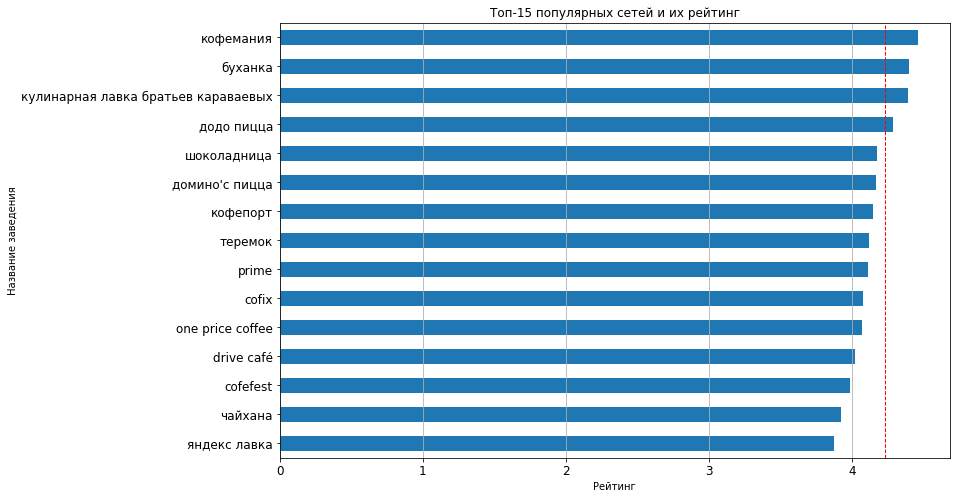

In [84]:
# Построим линейчатую диаграмму 
top_15.sort_values(by='mean_rating', ascending=True).plot(
    kind='barh', 
    x='name', 
    y='mean_rating', 
    xlabel='Название заведения',
    figsize=(12, 8),
    legend=False,
    title=('Топ-15 популярных сетей и их рейтинг'))

# Рассчитываем среднее значение по рейтинга
mean_rating_share = df_rest['rating'].mean()

# Наносим на график линию с средним значением рейтинга
plt.axvline(mean_rating_share, 
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Средний рейтинг {round(mean_rating_share,4)}')
    
# Увеличим размер шрифта меток на осях
plt.gca().tick_params(axis='both', which='major', labelsize=12)

# Добавим сетку для графика
plt.grid(axis='x')
plt.xlabel('Рейтинг')

# Выводим график
plt.show()

Самая популярная и самая большая сеть в Москве - `шоколадница` с типом кофейня - `120` заведений. Второе и третье место делят `домино'с пицца` и `додо пицца` с типом заведения `пиццерия`. Завершает топ-15 популярных сетей `кафе` `му-му` - `27` заведений. 

Рейтинги самых популярных сетей в основном ниже значения среднего рейтинга. Однако есть и такие, которые превышают значение среднего рейтинга. Например, `булочная буханка` и `кафе кулинарная лавка братьев караваевых` с рейтингом `4.4` у каждого. `яндекс лавка` самый низкий рейтинг `3.9`.

Среди популярных сетей наиболее часто втречаются категория `кофейня` в количестве `5` заведений. Далее категории `кафе` и `ресторан` по `3` заведения.

[Назад к содержанию](#17-bullet)

---
<a class="ancor" id="14-bullet"></a>
### Анализ цен в зависимости от округа

Изучим вариацию среднего чека заведения в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. Выясним как удалённость от центра влияет на цены в заведениях. Результат сопроводим подходящими визуализациями.


In [71]:
# Изучаем статистические показатели столбца 'middle_avg_bill'
display('Статистические показатели столбца middle_avg_bill:')
df_rest['middle_avg_bill'].describe()

'Статистические показатели столбца middle_avg_bill:'

count     3149.000000
mean       958.053650
std       1009.732849
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

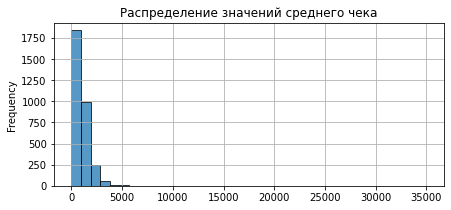

In [72]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df_rest['middle_avg_bill'].plot(
                kind='hist',
                xlabel='Средний чек',
                ylabel='Частота',
                bins=37, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
)

# Настраиваем оформление графика
plt.title('Распределение значений среднего чека')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

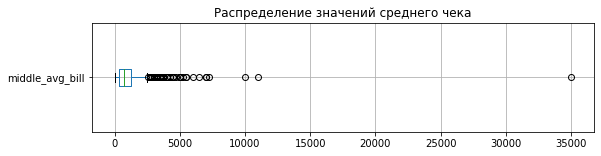

In [73]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(9, 2))

# Строим диаграмму размаха значений в столбце seats
df_rest.boxplot(column='middle_avg_bill', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений среднего чека')

# Выводим график
plt.show()

In [74]:
# Группируем среднее значение рейтинга по категориям
group_df_rest = df_rest.groupby('district')['middle_avg_bill'].agg(['median', 'mean'])

# Выводим результат
display(group_df_rest)

,median,mean
district,,
Восточный административный округ,575.0,820.626953
Западный административный округ,1000.0,1053.225464
Северный административный округ,650.0,927.959656
Северо-Восточный административный округ,500.0,716.611267
Северо-Западный административный округ,700.0,822.222900
Центральный административный округ,1000.0,1191.057495
Юго-Восточный административный округ,450.0,654.097961
Юго-Западный административный округ,600.0,792.561707
Южный административный округ,500.0,834.398071


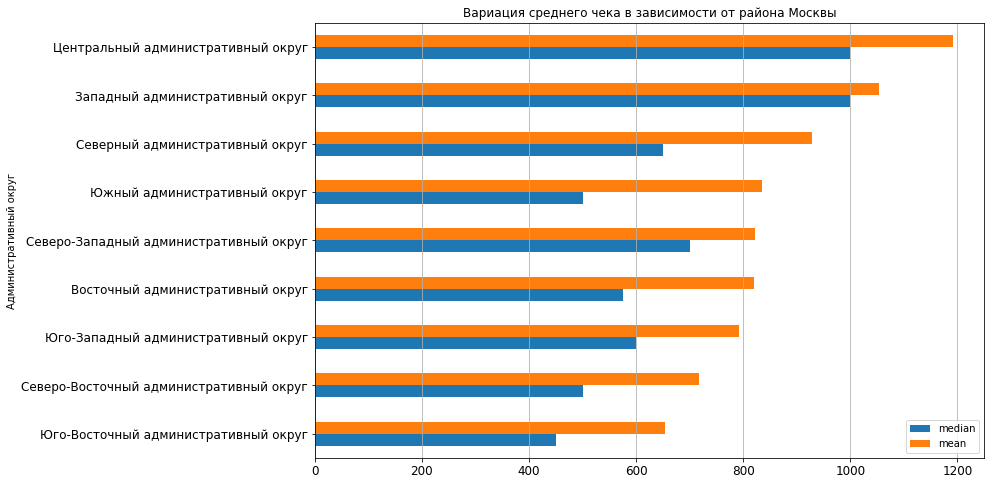

In [75]:
# Строим график линейчатую диаграммы
group_df_rest.sort_values(by='mean', ascending=True).plot(
               kind='barh',
               ylabel='Средний чек (руб.)',
               xlabel='Административный округ',     
               title='Вариация среднего чека в зависимости от района Москвы',
               legend=True,    
               rot=0,
               figsize=(12, 8))

# Увеличим размер шрифта меток на осях
plt.gca().tick_params(axis='both', which='major', labelsize=12)

# Добавим сетку на график
plt.grid(axis='x')

# Выводим график
plt.show() 

В `Центральном` административном округе г.Москвы средний чек выше чем в других районах и составляет приблизительно `1191 руб.`, медиана `1000 руб`. Самые низкие цены в `Юго-Восточном` округе Москвы - `654 руб.`, медиана `450 руб`.

---


In [76]:
# Фильтруем данные для Центрального административного округа
central_df = df_rest[df_rest['district'] == 'Центральный административный округ']

# Группируем данные для остальных районов и вычисляем средние цены
grouped_df = df_rest[df_rest['district'] != 'Центральный административный округ'].groupby('district')['middle_avg_bill'].mean().reset_index()

# Выводим статистические показатели для Центрального округа
display('Cтатистические показатели среднего чека для Центрального округа:')
central_df['middle_avg_bill'].describe()

'Cтатистические показатели среднего чека для Центрального округа:'

count    1060.000000
mean     1191.057495
std       920.014709
min         0.000000
25%       500.000000
50%      1000.000000
75%      1500.000000
max      7250.000000
Name: middle_avg_bill, dtype: float64

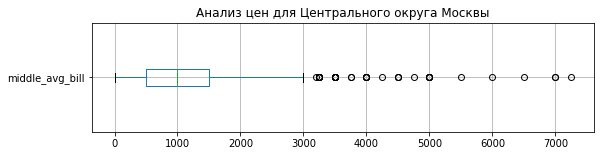

In [77]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(9, 2))

# Строим диаграмму размаха значений в столбце middle_avg_bill
central_df.boxplot(column='middle_avg_bill', vert=False)

# Добавляем заголовок и метки оси
plt.title('Анализ цен для Центрального округа Москвы')

# Выводим график
plt.show()

In [78]:
# Выводим статистические показатели для Центрального округа
display('Cтатистические показатели среднего чека для других округов:')
grouped_df['middle_avg_bill'].describe()

'Cтатистические показатели среднего чека для других округов:'

count       8.000000
mean      827.713013
std       122.329590
min       654.097961
25%       773.574097
50%       821.424927
75%       857.788467
max      1053.225464
Name: middle_avg_bill, dtype: float64

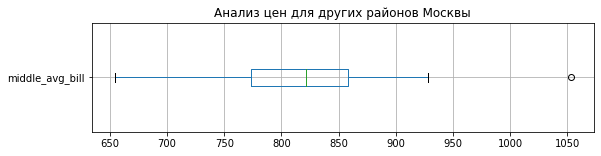

In [79]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(9, 2))

# Строим диаграмму размаха значений в столбце middle_avg_bill
grouped_df.boxplot(column='middle_avg_bill', vert=False)

# Добавляем заголовок и метки оси
plt.title('Анализ цен для других районов Москвы')

# Выводим график
plt.show()

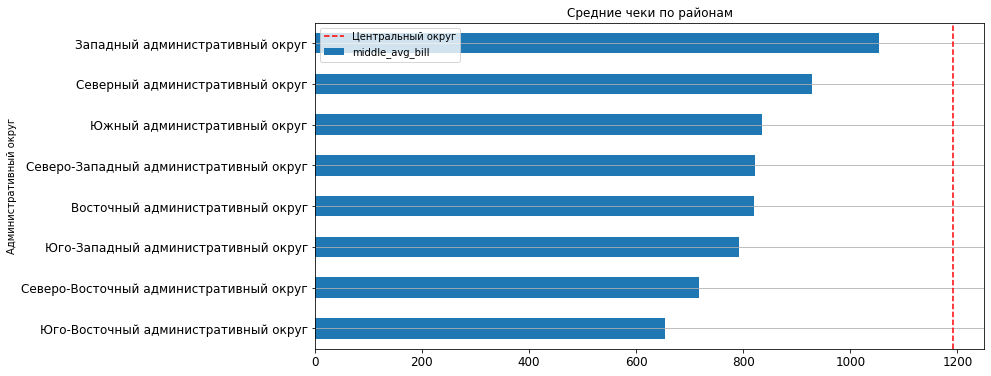

In [80]:
# Строим линейчатую диаграмму 
grouped_df.sort_values(by='middle_avg_bill', ascending=True).plot(
               kind='barh',
               x='district',
               xlabel='Административный округ',
               ylabel='Средний чек',
               legend=False,    
               rot=0,
               figsize=(12, 6))

# Создаем линию для обозначения среднего чека в Центральном округе
plt.axvline(
            central_df['middle_avg_bill'].mean(), 
            color='red', 
            linestyle='--', 
            label='Центральный округ')

# Увеличим размер шрифта меток на осях
plt.gca().tick_params(axis='both', which='major', labelsize=12)

# Оформляем график
plt.title('Средние чеки по районам')
plt.xticks(rotation=0)  
plt.legend()

plt.grid(axis='y')
plt.show()

Изучив данные, можно сказать, что цены заведений общественного питания в Центральном округе Москвы выше, чем в остальных районах. Это наглядно показывает линейчатая диаграмма выше. Максимальный средний чек в Центральном округе может составлять от 7250 рублей, что не является выбросом или аномалией. В остальных же районах максимальный средний чек от 1053 рубля.

[Назад к содержанию](#17-bullet)

---
<a class="ancor" id="15-bullet"></a>
### Промежуточный вывод

Обобщим полученные результаты:

* Категории кафе и ресторан значительно превышают в количестве остальные заведения.
* Самые популярные сети являются кафе с типом заведения кафе.
* В сетевых заведениях особенно часто встречается тип заведения булочная.
* Цены заведений общественного питания в Центральном окурге Москвы выше, чем в остальных районах. 
* В Центральном административном округе количество ресторанов превышает остальные заведения общественного питания 
* Распределение среднего значения рейтинга по категориям заведения показывает, что рейтинги заведений быстрое питание и кафе ниже общего среднего значения, но, в целом, отличие не сильное.
* Более низкий рейтинг у заведений с низкой ценовой категорией. Высокие рейтинги у заведений с высокой и выше среднего ценовых категорий.
* Самые высокие рейтинги в Центральном административном округе.

[Назад к содержанию](#17-bullet)

---
<a class="ancor" id="16-bullet"></a>
## 4. Итоговый вывод и рекомендации


В ходе исследования провели анализ данных рынка общественного питания в г.Москва. Данные включали наименования заведений,  и их характеристики, включая местоположение и режим работы. Для проведения исследований загрузили необходимые библиотеки для анализа данных и данные из датасетов `/datasets/rest_info.csv` и `/datasets/rest_price.csv`. Объединенный датасет содержит `13` столбцов и `8406` строк. `8` столбцов с типом данных `object`, `4` столбца с типом данных `float64` и `1` столбец с типом данных `int64`. 

В ходе проверки и предобработки данных, была проделана следующая работа:

* Провели оптимизацию типов данных путем понижения их разрядности некоторых столбцов: `rating`, `seats`, `middle_avg_bill`, `middle_coffee_cup` и `chain`;

* Для каждого случая обработали пропущенные значения: пропуски в столбце `seats` заполнили модой в зависимости от категории заведения; пропуски в столбце `hours` заменили на значение-индикатор; пропуски в столбцах `middle_avg_bill` и `middle_coffee_cup` заменили на среднее значение в зависимости от категории заведения и административного района, в котором находится заведение; пропуски в столбцах `price` и `avg_bill` оставили как есть. Оставшиеся пропущенные значения в столбце `middle_coffee_cup` тоже оставили как есть.

* Проверили и провели работу с явными и неявными дубликатами. В ходе предобработки данных дубликатов не выявлено;

* Провели исследовательский анализ исходных данных. При исследовании данных использовали визуализации.

Исследовательский анализ данных позволил сформировать некоторые выводы о заведениях общественного питания в районах Москвы:

* Категория `кафе` - лидер по количеству заведений в Москве `2378`. `Ресторанов` немного меньше - `2043` заведения.
* Самая популярная и самая большая сеть в Москве - `шоколадница` с типом `кофейня` - `120` заведений. Среди популярных сетей наиболее часто втречаются категория `кофейня` в количестве 5 заведений. Далее идут категории `кафе` и `ресторан` по 3 заведения.
* Более `низкий рейтинг` у заведений с `низкой ценовой` категорией. `Высокие рейтинги` у заведений с `высокой` и `выше среднего ценовых` категорий.

Результаты исследований показывают, что в Центральном административном округе количество заведений общественного питания превышают количество заведений в других районах Москвы. Средний чек также выше именно в Центральном округе и составляет `1130 рублей`, однако есть и более дорогие заведения в `Центральном` округе со средним чеком `7250 рублей`. В других районах нет такого разброса в данных со средним чеком.

Рейтинг заведений в `Центральном` округе также выше рейтинга заведений в других районах. 
`Круглосуточный` режим работы негативно сказывается на рейтинге заведения, судя по диаграмме `распределения рейтинга в зависимости от режима работы`.

Распределение среднего значения рейтинга по категориям заведения показывает, что рейтинги заведений `быстрое питание` и `кафе` ниже `общего среднего значения`. Лидерами по рейтингу являются категории `бар` - `4.39` и категории `пиццерия` и `ресторан` по `4.3`.

Анализ рынка показал, что наиболее подходящее место для заведения общественного питания - Центральный административный округ. Если выбирать тип заведения, то выбор можно сделать в пользу пиццерии, ресторана или бара, т.к. в основном у таких заведений рейтинг выше, чем у типа кафе или типа быстрое питание. По ценовой категории лучше выбрать среднюю ценовую категорию. 

[Назад к содержанию](#17-bullet)